# Phase 2 (Improved): Preprocessing & Augmentation Pipeline for Hindi HTR

**Fixes over previous Phase 2:**
1. ✅ No label corruption — val/test labels NEVER stripped
2. ✅ Correct column detection — hardcoded `text`, not `image_name`
3. ✅ Consistent TIGHT_CROP_PAD = 2
4. ✅ New augmentations — perspective, brightness/contrast
5. ✅ Character frequency artifact for Phase 3 WeightedRandomSampler
6. ✅ Roundtrip quality checks

**Platform:** Kaggle notebook


## 1. Configuration

In [1]:
from pathlib import Path

# ── Dataset (3 parquet files) ──
DATASET_DIR  = Path("/kaggle/input/datasets/nehamalik10/hindi-ocr-new-dataset")
TRAIN_FILE   = DATASET_DIR / "train.parquet"
VAL_FILE     = DATASET_DIR / "val.parquet"
TEST_FILE    = DATASET_DIR / "test.parquet"

# ── Output ──
OUTPUT_DIR   = Path("/kaggle/working/phase2_preprocessing")
PREVIEW_DIR  = OUTPUT_DIR / "previews"
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"

# ── Image config ──
IMG_HEIGHT, IMG_WIDTH = 32, 128
BINARIZATION_MODE = "otsu"
SKIP_BINARIZATION = False
INVERT_IMAGE      = False
KEEP_ASPECT_RATIO = True
TIGHT_CROP_PAD    = 2
DESKEW_MAX_ANGLE  = 15

# ── Column names (dataset has: image_name, image, text) ──
IMG_COL   = "image"
LABEL_COL = "text"

# ── Special tokens ──
BLANK_TOKEN, UNK_TOKEN, PAD_TOKEN = "<BLANK>", "<UNK>", "<PAD>"

# ── Augmentation probabilities (enhanced) ──
AUG_ROTATE_PROB       = 0.60
AUG_ELASTIC_PROB      = 0.50
AUG_NOISE_PROB        = 0.50
AUG_ERODE_DILATE_PROB = 0.25
AUG_SHEAR_PROB        = 0.55
AUG_CUTOUT_PROB       = 0.35
AUG_PERSPECTIVE_PROB  = 0.30
AUG_BRIGHTNESS_PROB   = 0.40

RANDOM_SEED = 42
BATCH_SIZE  = 32
NUM_WORKERS = 2

for d in [OUTPUT_DIR, PREVIEW_DIR, ARTIFACT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
print(f"Image: {IMG_HEIGHT}x{IMG_WIDTH} | TIGHT_CROP_PAD={TIGHT_CROP_PAD}")
print(f"Columns: IMG='{IMG_COL}', LABEL='{LABEL_COL}'")


Image: 32x128 | TIGHT_CROP_PAD=2
Columns: IMG='image', LABEL='text'


## 2. Install or Verify Dependencies

In [2]:
import subprocess, sys, importlib
required = {"numpy":"numpy","pandas":"pandas","matplotlib":"matplotlib",
            "PIL":"pillow","cv2":"opencv-python-headless","torch":"torch","pyarrow":"pyarrow"}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("All packages ready.")


All packages ready.


## 3. Imports, Seeds, and Device Check

In [3]:
import json, random, unicodedata, warnings, urllib.request, re
from collections import Counter
from io import BytesIO
from typing import Any

import cv2
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch.utils.data import Dataset, DataLoader

random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
print("Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))


Torch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


## 4. Devanagari Font Setup for Plots

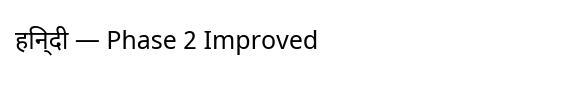

In [4]:
warnings.filterwarnings("ignore", message="Glyph.*missing from font")
FONT_DIR = Path("/kaggle/working/fonts"); FONT_DIR.mkdir(exist_ok=True)
FONT_PATH = FONT_DIR / "NotoSansDevanagari.ttf"
FONT_URL = "https://github.com/google/fonts/raw/main/ofl/notosansdevanagari/NotoSansDevanagari%5Bwdth%2Cwght%5D.ttf"

if not FONT_PATH.exists():
    for c in [Path("/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf"),
              Path("/tmp/NotoSansDevanagari.ttf")]:
        if c.exists(): FONT_PATH.write_bytes(c.read_bytes()); break
    else:
        print("Downloading font..."); urllib.request.urlretrieve(FONT_URL, FONT_PATH)

fm.fontManager.addfont(str(FONT_PATH))
DEVA_FONT = fm.FontProperties(fname=str(FONT_PATH))
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(7, 1))
plt.text(0.01, 0.5, "हिन्दी — Phase 2 Improved", fontsize=18, fontproperties=DEVA_FONT)
plt.axis("off"); plt.show()


## 5. Verify Dataset Files

In [5]:
all_files = [TRAIN_FILE, VAL_FILE, TEST_FILE]
for p in all_files:
    assert p.exists(), f"Missing: {p}"
    print(f"  {p.name:25s} {p.stat().st_size/(1024*1024):.1f} MB")


  train.parquet             1899.4 MB
  val.parquet               236.3 MB
  test.parquet              421.2 MB


## 6. Load Train, Validation, and Test Splits

In [6]:
train_df = pd.read_parquet(TRAIN_FILE)
val_df   = pd.read_parquet(VAL_FILE)
test_df  = pd.read_parquet(TEST_FILE)

split_sizes = {"train": len(train_df), "val": len(val_df), "test": len(test_df)}
for name, count in split_sizes.items():
    print(f"  {name:5s}: {count:>7,}")

with (ARTIFACT_DIR / "split_sizes.json").open("w") as f:
    json.dump(split_sizes, f, indent=2)

print(f"\nColumns: {train_df.columns.tolist()}")
print("\nDtypes:")
print(train_df.dtypes)


  train: 150,000
  val  :  20,000
  test :  30,000

Columns: ['image_name', 'image', 'text']

Dtypes:
image_name    object
image         object
text          object
dtype: object


## 7. Image Decoding Helper

Sample image size: (168, 247)
Sample label: के


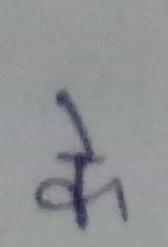

In [7]:
def row_to_image(row, image_col=IMG_COL):
    value = row[image_col]
    if isinstance(value, Image.Image):
        return value.convert("RGB")
    if isinstance(value, dict):
        if value.get("bytes") is not None:
            return Image.open(BytesIO(value["bytes"])).convert("RGB")
        if value.get("path") is not None:
            return Image.open(value["path"]).convert("RGB")
    if isinstance(value, (bytes, bytearray)):
        return Image.open(BytesIO(value)).convert("RGB")
    if isinstance(value, np.ndarray):
        return Image.fromarray(value).convert("RGB")
    if isinstance(value, (str, Path)):
        return Image.open(value).convert("RGB")
    raise TypeError(f"Unsupported image type: {type(value)}")

sample_image = row_to_image(train_df.iloc[0])
print(f"Sample image size: {sample_image.size}")
print(f"Sample label: {train_df.iloc[0][LABEL_COL]}")
display(sample_image)


## 8. Visualize Raw Training Samples

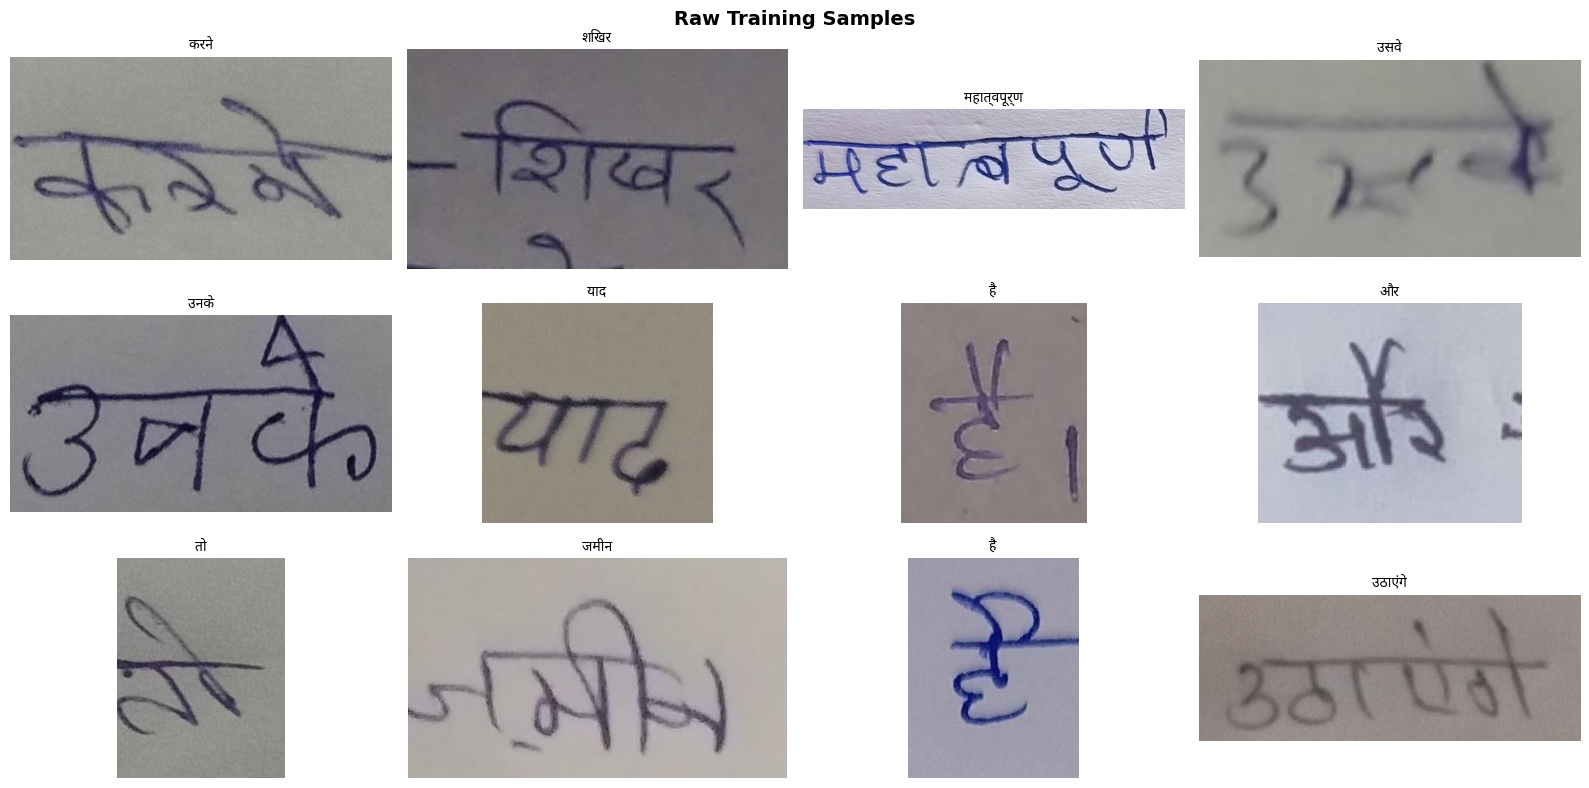

In [8]:
sample_count = min(12, len(train_df))
sample_indices = np.random.choice(len(train_df), sample_count, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, idx in zip(axes, sample_indices):
    row = train_df.iloc[idx]
    ax.imshow(row_to_image(row))
    ax.set_title(str(row[LABEL_COL]), fontsize=12, fontproperties=DEVA_FONT)
    ax.axis("off")
for ax in axes[sample_count:]:
    ax.axis("off")
plt.suptitle("Raw Training Samples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "raw_samples.png", dpi=160, bbox_inches="tight")
plt.show()


## 9. Image Dimension Analysis

Check image size distribution — aspect-ratio variation matters because naive stretching distorts handwriting.


,width,height,aspect_ratio
count,3000.000000,3000.000000,3000.000000
mean,315.816333,202.251333,1.650025
std,138.046266,56.399248,0.804731
min,54.000000,34.000000,0.455696
25%,212.000000,160.750000,1.086254
50%,293.500000,202.000000,1.519502
75%,390.000000,243.000000,2.057486
max,1268.000000,406.000000,17.823529


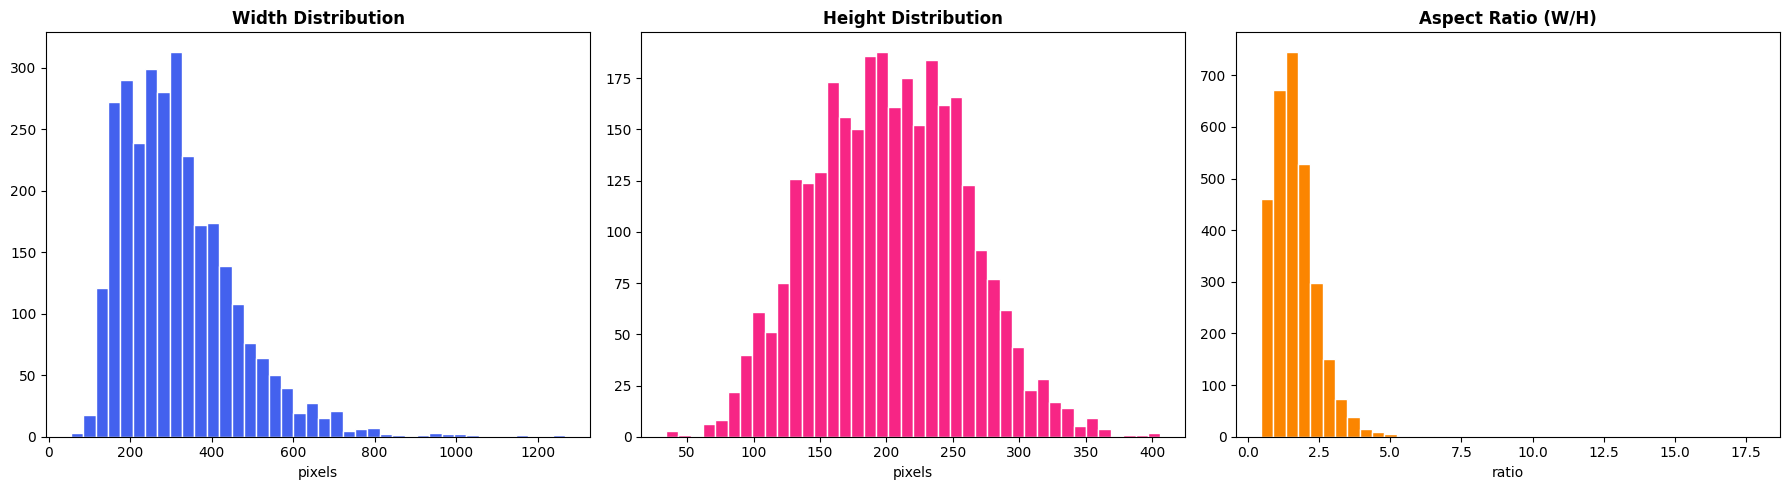

In [9]:
dim_sample_size = min(3000, len(train_df))
dim_indices = np.random.choice(len(train_df), dim_sample_size, replace=False)

rows = []
for idx in dim_indices:
    img = row_to_image(train_df.iloc[idx])
    w, h = img.size
    rows.append({"width": w, "height": h, "aspect_ratio": w / max(h, 1)})

dim_df = pd.DataFrame(rows)
display(dim_df.describe())
dim_df.to_csv(ARTIFACT_DIR / "image_dimension_sample.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(dim_df["width"], bins=40, color="#4361ee", edgecolor="white")
axes[0].set_title("Width Distribution", fontweight="bold"); axes[0].set_xlabel("pixels")
axes[1].hist(dim_df["height"], bins=40, color="#f72585", edgecolor="white")
axes[1].set_title("Height Distribution", fontweight="bold"); axes[1].set_xlabel("pixels")
axes[2].hist(dim_df["aspect_ratio"], bins=40, color="#fb8500", edgecolor="white")
axes[2].set_title("Aspect Ratio (W/H)", fontweight="bold"); axes[2].set_xlabel("ratio")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "dimension_analysis.png", dpi=160, bbox_inches="tight")
plt.show()


## 10. Label Normalization and Character Vocabulary

Vocab built from **training labels only** (no leakage). Labels are **NEVER stripped**.


In [10]:
def normalize_label(text: Any) -> str:
    return " ".join(unicodedata.normalize("NFC", str(text)).strip().split())

train_labels = [normalize_label(x) for x in train_df[LABEL_COL]]
val_labels   = [normalize_label(x) for x in val_df[LABEL_COL]]
test_labels  = [normalize_label(x) for x in test_df[LABEL_COL]]

char_counter = Counter("".join(train_labels))
characters = sorted(char_counter.keys())

char_to_idx = {BLANK_TOKEN: 0}
for i, ch in enumerate(characters, start=1):
    char_to_idx[ch] = i
unk_idx = len(char_to_idx); char_to_idx[UNK_TOKEN] = unk_idx
pad_idx = len(char_to_idx); char_to_idx[PAD_TOKEN] = pad_idx
blank_idx = 0
idx_to_char = {v: k for k, v in char_to_idx.items()}
NUM_CLASSES = len(char_to_idx)

print(f"Vocabulary: {NUM_CLASSES} classes ({len(characters)} data + 3 special)")
print(f"  BLANK={blank_idx}, UNK={unk_idx}, PAD={pad_idx}")

print("\nMost common characters:")
for ch, cnt in char_counter.most_common(25):
    name = unicodedata.name(ch, "UNKNOWN")
    print(f"  '{ch}' (U+{ord(ch):04X}) {name:40s}: {cnt:>8,}")

for name, labels in [("val", val_labels), ("test", test_labels)]:
    unk = sorted(set("".join(labels)) - set(characters))
    if unk:
        print(f"\n  {name}: {len(unk)} unknown chars: {unk}")
        print(f"  (Will map to UNK_IDX={unk_idx} — labels NOT modified)")
    else:
        print(f"  {name}: all characters in vocab")

vocab_data = {
    "char_to_idx": char_to_idx,
    "idx_to_char": {str(k): v for k, v in idx_to_char.items()},
    "blank_idx": blank_idx, "unk_idx": unk_idx, "pad_idx": pad_idx,
    "unicode_normalization": "NFC",
}
with (ARTIFACT_DIR / "char_vocab.json").open("w", encoding="utf-8") as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)
print(f"\nSaved: {ARTIFACT_DIR / 'char_vocab.json'}")


Vocabulary: 139 classes (136 data + 3 special)
  BLANK=0, UNK=137, PAD=138

Most common characters:
  'ा' (U+093E) DEVANAGARI VOWEL SIGN AA                :   57,298
  'र' (U+0930) DEVANAGARI LETTER RA                    :   41,278
  'क' (U+0915) DEVANAGARI LETTER KA                    :   40,758
  'े' (U+0947) DEVANAGARI VOWEL SIGN E                 :   36,846
  '्' (U+094D) DEVANAGARI SIGN VIRAMA                  :   31,599
  'न' (U+0928) DEVANAGARI LETTER NA                    :   27,504
  'ि' (U+093F) DEVANAGARI VOWEL SIGN I                 :   26,019
  'त' (U+0924) DEVANAGARI LETTER TA                    :   25,938
  'ह' (U+0939) DEVANAGARI LETTER HA                    :   25,354
  'स' (U+0938) DEVANAGARI LETTER SA                    :   24,807
  'ी' (U+0940) DEVANAGARI VOWEL SIGN II                :   22,863
  'म' (U+092E) DEVANAGARI LETTER MA                    :   21,737
  'ं' (U+0902) DEVANAGARI SIGN ANUSVARA                :   19,999
  'प' (U+092A) DEVANAGARI LETTER PA       

## 11. Label Length and Unicode Analysis

Catches Hindi-specific issues: long labels, unexpected punctuation, combining marks.


Train label length summary:


count    150000.000000
mean          4.234093
std           2.074069
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max          19.000000
Name: label_length, dtype: float64


Unicode categories present:
  Cf: 2 chars (e.g. ‍, ‌)
  Ll: 5 chars (e.g. d, a, h)
  Lo: 56 chars (e.g. र, क, न)
  Lu: 4 chars (e.g. A, N, J)
  Mc: 8 chars (e.g. ा, ि, ी)
  Mn: 15 chars (e.g. े, ्, ं)
  Nd: 20 chars (e.g. ०, २, १)
  Pc: 1 chars (e.g. _)
  Pd: 1 chars (e.g. -)
  Pe: 1 chars (e.g. ))
  Pf: 1 chars (e.g. ”)
  Pi: 1 chars (e.g. “)
  Po: 15 chars (e.g. ।, ., ,)
  Ps: 1 chars (e.g. ()
  Sm: 4 chars (e.g. >, =, +)
  Zs: 1 chars (e.g.  )


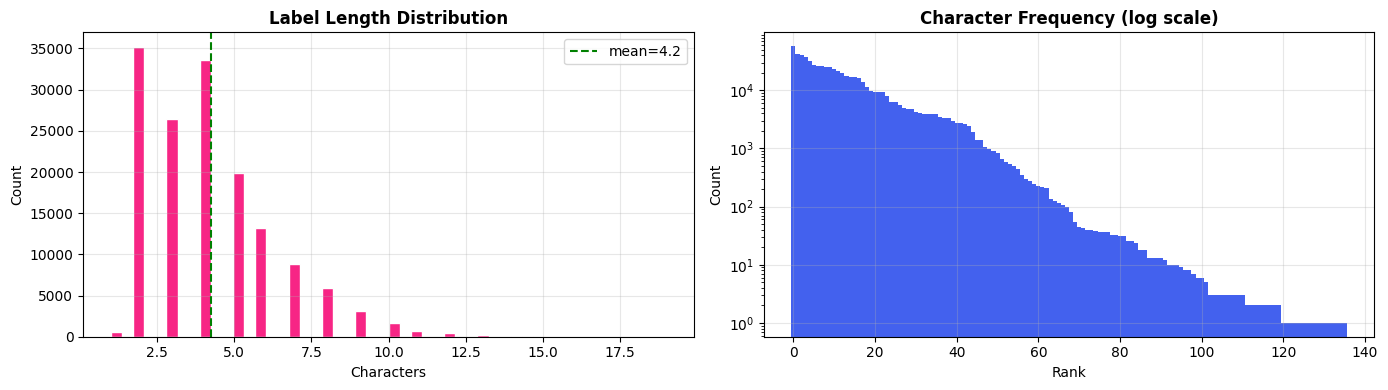

In [11]:
label_lengths = pd.Series([len(lbl) for lbl in train_labels], name="label_length")
print("Train label length summary:")
display(label_lengths.describe())

unicode_rows = []
for char in characters:
    unicode_rows.append({
        "char": char, "codepoint": f"U+{ord(char):04X}",
        "category": unicodedata.category(char),
        "name": unicodedata.name(char, "UNKNOWN"),
        "count": char_counter[char],
    })
unicode_df = pd.DataFrame(unicode_rows).sort_values("count", ascending=False)
unicode_df.to_csv(ARTIFACT_DIR / "unicode_character_analysis.csv", index=False, encoding="utf-8")

print(f"\nUnicode categories present:")
for cat, group in unicode_df.groupby("category"):
    print(f"  {cat}: {len(group)} chars (e.g. {', '.join(group['char'].head(3))})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.hist(label_lengths, bins=50, color="#f72585", edgecolor="white")
ax1.set_title("Label Length Distribution", fontweight="bold")
ax1.set_xlabel("Characters"); ax1.set_ylabel("Count")
ax1.axvline(label_lengths.mean(), color="green", ls="--", label=f"mean={label_lengths.mean():.1f}")
ax1.legend(); ax1.grid(alpha=0.3)

freqs = sorted(char_counter.values(), reverse=True)
ax2.bar(range(len(freqs)), freqs, color="#4361ee", width=1.0)
ax2.set_title("Character Frequency (log scale)", fontweight="bold")
ax2.set_xlabel("Rank"); ax2.set_ylabel("Count"); ax2.set_yscale("log"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PREVIEW_DIR / "label_unicode_analysis.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Character Frequency Artifact

In [12]:
char_freq = {}
for ch, cnt in char_counter.items():
    idx = char_to_idx.get(ch, unk_idx)
    char_freq[str(idx)] = {"char": ch, "count": cnt, "codepoint": f"U+{ord(ch):04X}"}
with (ARTIFACT_DIR / "char_frequencies.json").open("w", encoding="utf-8") as f:
    json.dump(char_freq, f, ensure_ascii=False, indent=2)
print(f"Saved: {ARTIFACT_DIR / 'char_frequencies.json'} ({len(char_freq)} entries)")


Saved: /kaggle/working/phase2_preprocessing/artifacts/char_frequencies.json (136 entries)


## 13. Core Preprocessing Functions

Pipeline: grayscale → auto-contrast → denoise → deskew → tight crop → binarize → ensure black text → resize with padding → normalize to [-1, 1]

Final tensor shape: `(1, 32, 128)`


In [13]:
def pil_to_gray_np(image):
    return np.array(image.convert("L"))

def autocontrast_gray(gray):
    return np.array(ImageOps.autocontrast(Image.fromarray(gray)))

def denoise_gray(gray):
    return cv2.medianBlur(gray, 3)

def binarize_gray(gray, mode=BINARIZATION_MODE):
    if mode == "otsu":
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif mode == "adaptive":
        binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY, 21, 11)
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return binary

def ensure_black_text(img):
    if INVERT_IMAGE or np.mean(img < 128) > 0.55:
        return 255 - img
    return img

def deskew_image(img):
    coords = np.column_stack(np.where(img < 128))
    if len(coords) < 10:
        return img
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) > DESKEW_MAX_ANGLE:
        return img
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)

def tight_crop(img, pad=TIGHT_CROP_PAD):
    coords = np.column_stack(np.where(img < 200))
    if len(coords) == 0:
        return img
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0)
    y0, x0 = max(0, y0 - pad), max(0, x0 - pad)
    y1 = min(img.shape[0], y1 + pad + 1)
    x1 = min(img.shape[1], x1 + pad + 1)
    cropped = img[y0:y1, x0:x1]
    return cropped if cropped.size > 0 else img

def resize_with_padding(img, target_h=IMG_HEIGHT, target_w=IMG_WIDTH):
    h, w = img.shape
    if h <= 0 or w <= 0:
        return np.full((target_h, target_w), 255, dtype=np.uint8)
    if KEEP_ASPECT_RATIO:
        scale = min(target_w / w, target_h / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        canvas = np.full((target_h, target_w), 255, dtype=np.uint8)
        x0 = (target_w - new_w) // 2
        y0 = (target_h - new_h) // 2
        canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
        return canvas
    return cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_AREA)

def normalize_image(image):
    return (image.astype(np.float32) / 255.0 - 0.5) / 0.5

def preprocess_image(image, return_steps=False):
    gray      = pil_to_gray_np(image)
    contrast  = autocontrast_gray(gray)
    denoised  = denoise_gray(contrast)
    deskewed  = deskew_image(denoised)
    cropped   = tight_crop(deskewed)
    if SKIP_BINARIZATION:
        processed = ensure_black_text(cropped)
    else:
        processed = ensure_black_text(binarize_gray(cropped))
    resized    = resize_with_padding(processed)
    normalized = normalize_image(resized)
    if return_steps:
        return {"gray": gray, "contrast": contrast, "denoised": denoised,
                "deskewed": deskewed, "cropped": cropped, "processed": processed,
                "resized": resized, "normalized": normalized}
    return normalized

print("Preprocessing functions loaded.")


Preprocessing functions loaded.


## 14. Preprocessing Step-by-Step Preview

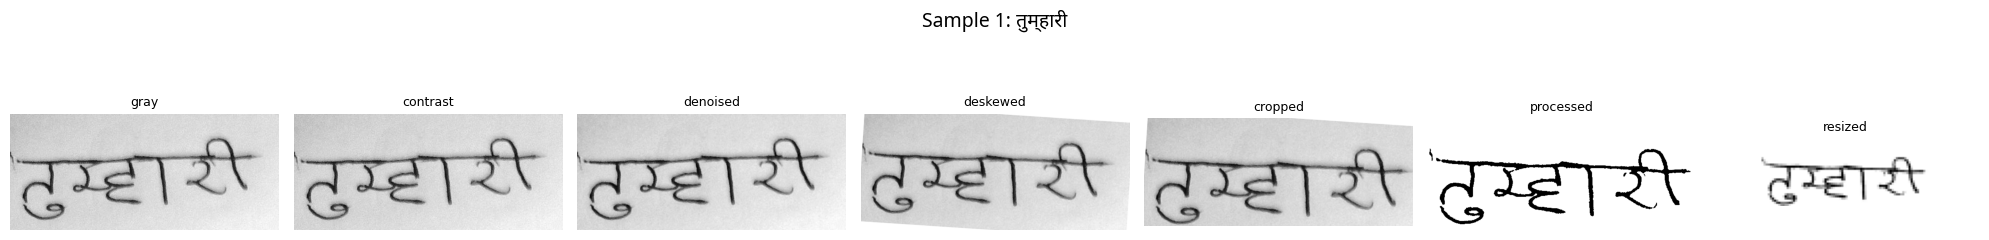

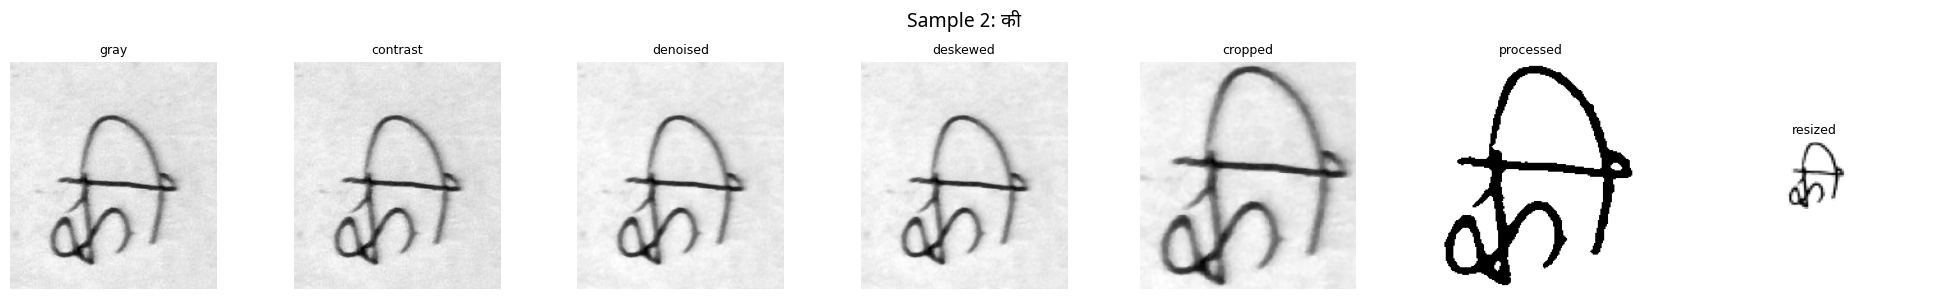

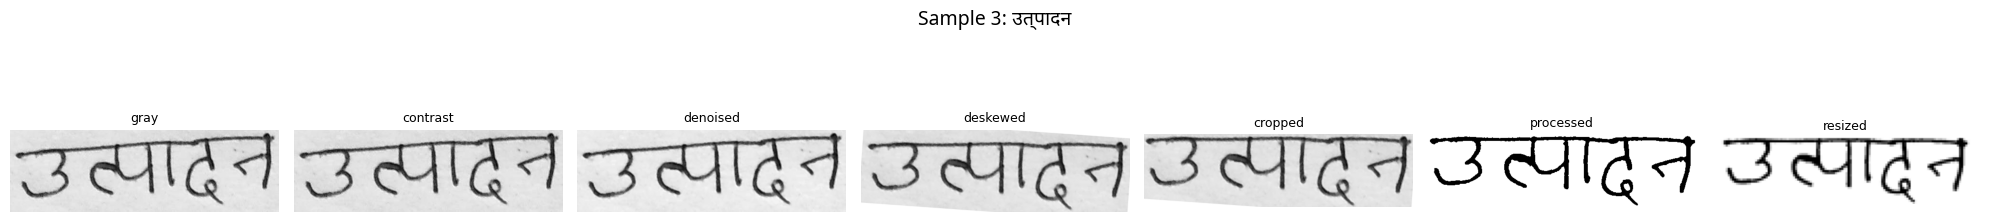

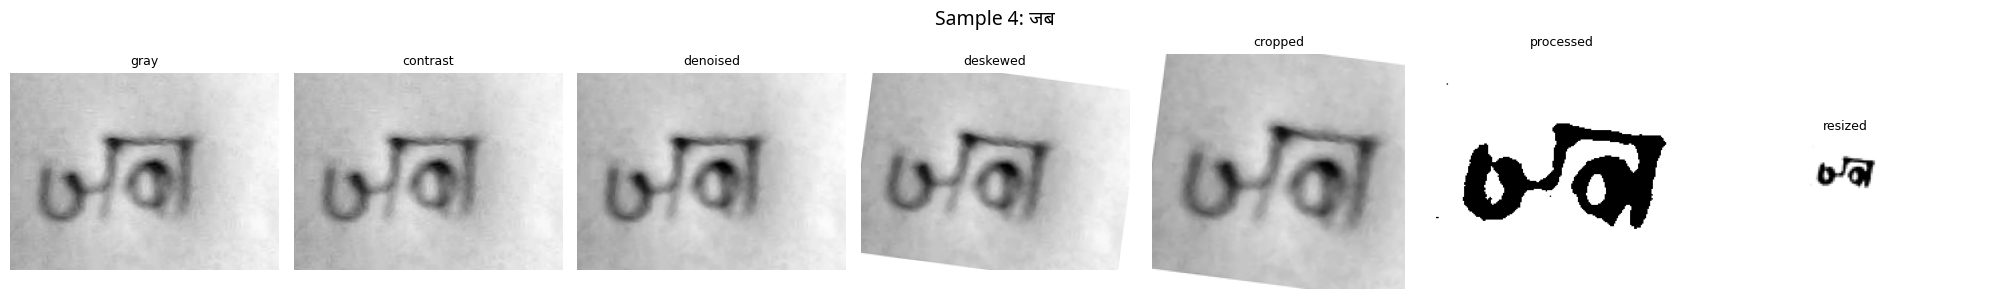

In [14]:
preview_indices = np.random.choice(len(train_df), min(4, len(train_df)), replace=False)
stage_names = ["gray", "contrast", "denoised", "deskewed", "cropped", "processed", "resized"]

for si, idx in enumerate(preview_indices, 1):
    row   = train_df.iloc[idx]
    image = row_to_image(row)
    steps = preprocess_image(image, return_steps=True)
    label = normalize_label(row[LABEL_COL])

    fig, axes = plt.subplots(1, len(stage_names), figsize=(20, 3))
    fig.suptitle(f"Sample {si}: {label}", fontsize=14, fontproperties=DEVA_FONT)
    for ax, name in zip(axes, stage_names):
        ax.imshow(steps[name], cmap="gray")
        ax.set_title(name, fontsize=9); ax.axis("off")
    plt.tight_layout()
    plt.savefig(PREVIEW_DIR / f"preprocess_{si}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 15. Data Augmentation Functions

**8 augmentation types:** rotation, elastic distortion, perspective (NEW),
brightness/contrast (NEW), noise, erode/dilate, shear, cutout


In [15]:
def random_rotation(image, max_angle=5.0):
    angle = random.uniform(-max_angle, max_angle)
    h, w = image.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def elastic_distortion(image, alpha=7.0, sigma=4.0):
    h, w = image.shape
    dx = cv2.GaussianBlur(np.random.uniform(-1, 1, (h, w)).astype(np.float32), (0, 0), sigma) * alpha
    dy = cv2.GaussianBlur(np.random.uniform(-1, 1, (h, w)).astype(np.float32), (0, 0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    return cv2.remap(image, (x + dx).astype(np.float32), (y + dy).astype(np.float32),
                     interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=255)

def add_noise(image, std=10.0):
    noise = np.random.normal(0, std, image.shape).astype(np.float32)
    return np.clip(image.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def random_erode_dilate(image):
    kernel = np.ones((2, 2), np.uint8)
    return cv2.erode(image, kernel, 1) if random.random() < 0.5 else cv2.dilate(image, kernel, 1)

def random_shear(image, max_shear_deg=12.0):
    h, w = image.shape
    s = np.radians(random.uniform(-max_shear_deg, max_shear_deg))
    M = np.array([[1, s, -s * h / 2], [0, 1, 0]], dtype=np.float32)
    return cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=255)

def random_cutout(image, num_patches=3, patch_size=4):
    result = image.copy()
    h, w = result.shape
    for _ in range(random.randint(1, num_patches)):
        y = random.randint(0, max(0, h - patch_size))
        x = random.randint(0, max(0, w - patch_size))
        result[y:y + patch_size, x:x + patch_size] = 255
    return result

def random_perspective(image, scale=0.05):
    h, w = image.shape
    mx, my = max(1, int(w * scale)), max(1, int(h * scale))
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([
        [random.randint(0, mx), random.randint(0, my)],
        [w - random.randint(0, mx), random.randint(0, my)],
        [w - random.randint(0, mx), h - random.randint(0, my)],
        [random.randint(0, mx), h - random.randint(0, my)]
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(image, M, (w, h), borderValue=255)

def random_brightness_contrast(image, br=0.3, cr=0.3):
    img = image.astype(np.float32)
    alpha = 1.0 + random.uniform(-cr, cr)
    beta  = random.uniform(-br, br) * 255
    return np.clip(alpha * img + beta, 0, 255).astype(np.uint8)

def augment_image(image):
    aug = image.copy()
    if random.random() < AUG_ROTATE_PROB:       aug = random_rotation(aug)
    if random.random() < AUG_ELASTIC_PROB:      aug = elastic_distortion(aug)
    if random.random() < AUG_PERSPECTIVE_PROB:  aug = random_perspective(aug)
    if random.random() < AUG_BRIGHTNESS_PROB:   aug = random_brightness_contrast(aug)
    if random.random() < AUG_NOISE_PROB:        aug = add_noise(aug)
    if random.random() < AUG_ERODE_DILATE_PROB: aug = random_erode_dilate(aug)
    if random.random() < AUG_SHEAR_PROB:        aug = random_shear(aug)
    if random.random() < AUG_CUTOUT_PROB:       aug = random_cutout(aug)
    return aug

print("8 augmentation functions loaded.")


8 augmentation functions loaded.


## 16. Augmentation Preview

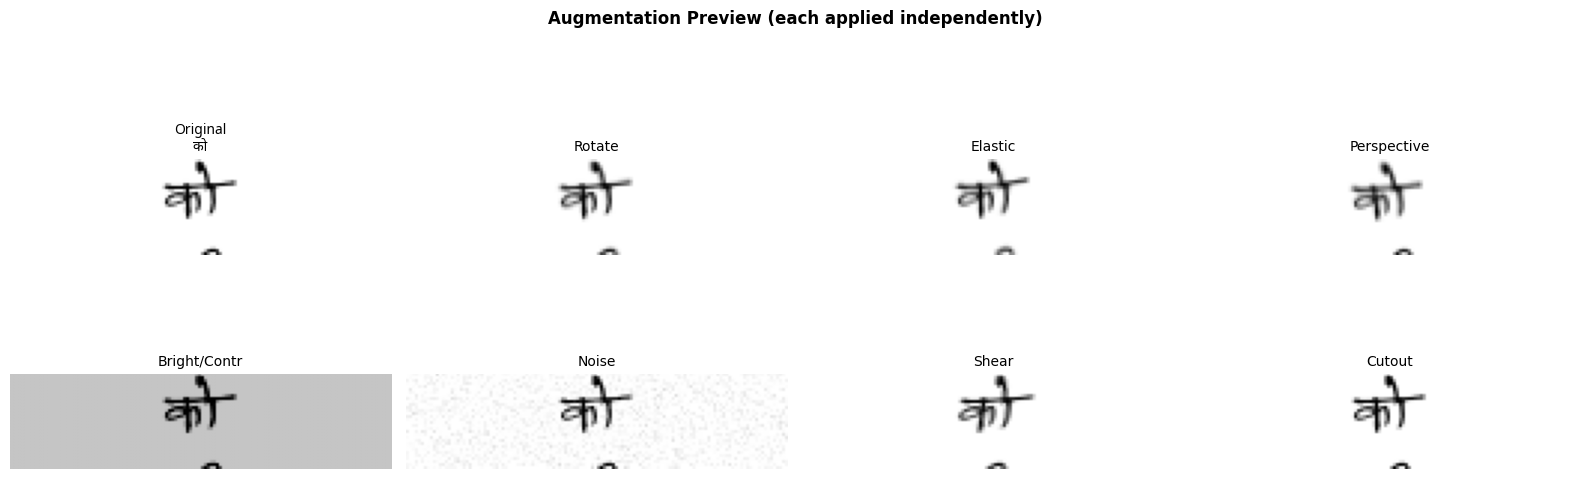

In [16]:
row   = train_df.iloc[np.random.randint(0, len(train_df))]
image = row_to_image(row)
steps = preprocess_image(image, return_steps=True)
base  = steps["resized"]
label = normalize_label(row[LABEL_COL])

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(base, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{label}", fontproperties=DEVA_FONT, fontsize=10)
axes[0].axis("off")

aug_names = ["Rotate", "Elastic", "Perspective", "Bright/Contr", "Noise", "Shear", "Cutout"]
aug_fns   = [random_rotation, elastic_distortion, random_perspective,
             random_brightness_contrast, add_noise, random_shear, random_cutout]
for ax, name, fn in zip(axes[1:], aug_names, aug_fns):
    ax.imshow(fn(base.copy()), cmap="gray", vmin=0, vmax=255)
    ax.set_title(name, fontsize=10); ax.axis("off")

plt.suptitle("Augmentation Preview (each applied independently)", fontweight="bold")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "augmentation_preview.png", dpi=150, bbox_inches="tight")
plt.show()


## 17. Label Encoding and Decoding

In [17]:
def encode_label(label):
    return [char_to_idx.get(ch, unk_idx) for ch in normalize_label(label)]

def decode_indices(indices):
    return "".join(idx_to_char.get(int(i), "") for i in indices
                   if int(i) not in {blank_idx, pad_idx})

# Roundtrip verification
print("Roundtrip encode-decode test:")
for name, labels in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
    n = min(100, len(labels))
    ok = 0
    for i in range(n):
        lbl = labels[i]
        decoded = decode_indices(encode_label(lbl))
        clean = decoded.replace(UNK_TOKEN, "").replace(BLANK_TOKEN, "").replace(PAD_TOKEN, "")
        has_unk = any(ch not in char_to_idx for ch in lbl)
        if has_unk or lbl == clean:
            ok += 1
    print(f"  {name}: {ok}/{n} passed")


Roundtrip encode-decode test:
  train: 100/100 passed
  val: 100/100 passed
  test: 100/100 passed


## 18. PyTorch Dataset Class

In [18]:
class HindiHTRDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = normalize_label(str(row[LABEL_COL]))
        try:
            pil_img = row_to_image(row)
        except Exception:
            img   = torch.zeros(1, IMG_HEIGHT, IMG_WIDTH, dtype=torch.float32)
            label = torch.IntTensor([blank_idx])
            return {"image": img, "label": label, "label_length": 1, "text": ""}

        steps   = preprocess_image(pil_img, return_steps=True)
        resized = steps["resized"]
        if self.augment:
            resized = augment_image(resized)
        normalized = normalize_image(resized)

        img   = torch.FloatTensor(normalized).unsqueeze(0)
        label = torch.IntTensor(encode_label(text))
        return {"image": img, "label": label, "label_length": len(label), "text": text}

print("HindiHTRDataset defined.")


HindiHTRDataset defined.


## 19. DataLoader and Collate Function

In [19]:
def htr_collate_fn(batch):
    images  = torch.stack([item["image"] for item in batch])
    lengths = torch.tensor([item["label_length"] for item in batch], dtype=torch.long)
    max_len = int(lengths.max().item()) if len(lengths) else 0
    labels  = torch.full((len(batch), max_len), fill_value=pad_idx, dtype=torch.long)
    for i, item in enumerate(batch):
        L = item["label_length"]
        labels[i, :L] = item["label"]
    texts = [item["text"] for item in batch]
    return {"images": images, "labels": labels, "label_lengths": lengths, "texts": texts}

train_dataset = HindiHTRDataset(train_df, augment=True)
val_dataset   = HindiHTRDataset(val_df,   augment=False)
test_dataset  = HindiHTRDataset(test_df,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=htr_collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=htr_collate_fn, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=htr_collate_fn, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")


Train: 4688 batches | Val: 625 | Test: 938


## 20. Batch Visualization

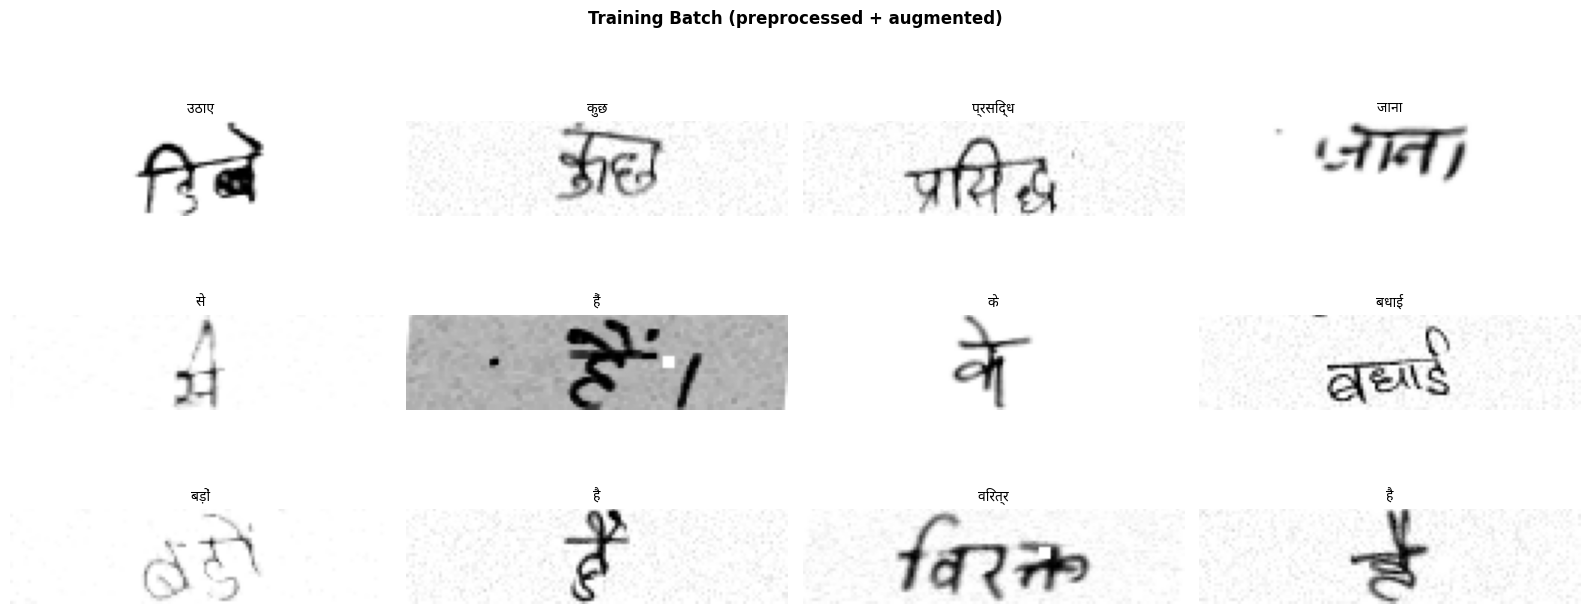

In [20]:
def tensor_to_display(t):
    img = t.squeeze(0).detach().cpu().numpy()
    return np.clip((img * 0.5 + 0.5) * 255, 0, 255).astype(np.uint8)

batch = next(iter(train_loader))
n_show = min(12, batch["images"].shape[0])

fig, axes = plt.subplots(3, 4, figsize=(16, 7))
axes = axes.flatten()
for i in range(n_show):
    axes[i].imshow(tensor_to_display(batch["images"][i]), cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(batch["texts"][i], fontproperties=DEVA_FONT, fontsize=10)
    axes[i].axis("off")
for i in range(n_show, len(axes)):
    axes[i].axis("off")

plt.suptitle("Training Batch (preprocessed + augmented)", fontweight="bold")
plt.tight_layout()
plt.savefig(PREVIEW_DIR / "batch_viz.png", dpi=150, bbox_inches="tight")
plt.show()


## 21. Quality Checks

In [21]:
print("=" * 60)
print("QUALITY CHECKS")
print("=" * 60)

sample = train_dataset[0]
assert sample["image"].shape == (1, IMG_HEIGHT, IMG_WIDTH)
print(f"  Image shape : {sample['image'].shape}")

v = sample["image"]
assert v.min() >= -1.1 and v.max() <= 1.1
print(f"  Value range : [{v.min():.2f}, {v.max():.2f}]")

b = next(iter(train_loader))
assert b["images"].shape[-2:] == (IMG_HEIGHT, IMG_WIDTH)
print(f"  Batch shape : {b['images'].shape}")

print("\n  Label content verification:")
for i in range(5):
    lbl = train_df[LABEL_COL].iloc[i]
    has_devanagari = any('\u0900' <= ch <= '\u097F' for ch in str(lbl))
    print(f"    [{i}] '{lbl}' Devanagari: {has_devanagari}")

top_chars = [ch for ch, _ in char_counter.most_common(5)]
deva_count = sum(1 for ch in top_chars if '\u0900' <= ch <= '\u097F')
print(f"\n  Top-5 chars Devanagari: {deva_count}/5", "✓" if deva_count >= 3 else "✗ WARNING")

print("\n" + "=" * 60)
print("QUALITY CHECKS COMPLETE")
print("=" * 60)


QUALITY CHECKS
  Image shape : torch.Size([1, 32, 128])
  Value range : [-0.73, 1.00]
  Batch shape : torch.Size([32, 1, 32, 128])

  Label content verification:
    [0] 'के' Devanagari: True
    [1] 'फिर' Devanagari: True
    [2] 'से' Devanagari: True
    [3] 'करने' Devanagari: True
    [4] 'लगा' Devanagari: True

  Top-5 chars Devanagari: 5/5 ✓

QUALITY CHECKS COMPLETE


## 22. Save Pipeline Configuration and Sample Batch

In [22]:
pipeline_config = {
    "image_height": IMG_HEIGHT, "image_width": IMG_WIDTH,
    "binarization_mode": BINARIZATION_MODE,
    "invert_image": INVERT_IMAGE,
    "keep_aspect_ratio": KEEP_ASPECT_RATIO,
    "normalization": "image / 255 -> (x - 0.5) / 0.5, range [-1, 1]",
    "blank_token": BLANK_TOKEN, "unk_token": UNK_TOKEN, "pad_token": PAD_TOKEN,
    "blank_idx": blank_idx, "unk_idx": unk_idx, "pad_idx": pad_idx,
    "batch_size": BATCH_SIZE,
    "augmentations": {
        "rotation_degrees": [-5, 5],
        "elastic_distortion": True, "noise_addition": True,
        "erode_dilate": True, "shear_slant_degrees": [-12, 12],
        "cutout_coarse_dropout": True,
        "perspective_transform": True,
        "brightness_contrast_jitter": True,
        "probabilities": {
            "rotation": AUG_ROTATE_PROB, "elastic": AUG_ELASTIC_PROB,
            "noise": AUG_NOISE_PROB, "erode_dilate": AUG_ERODE_DILATE_PROB,
            "shear": AUG_SHEAR_PROB, "cutout": AUG_CUTOUT_PROB,
            "perspective": AUG_PERSPECTIVE_PROB,
            "brightness_contrast": AUG_BRIGHTNESS_PROB,
        },
    },
    "skip_binarization": SKIP_BINARIZATION,
    "tight_crop_pad": TIGHT_CROP_PAD,
    "split_sizes": split_sizes,
    "image_column": IMG_COL,
    "label_column": LABEL_COL,
}

with (ARTIFACT_DIR / "preprocess_config.json").open("w", encoding="utf-8") as f:
    json.dump(pipeline_config, f, ensure_ascii=False, indent=2)

sample_batch = next(iter(train_loader))
torch.save({
    "images": sample_batch["images"],
    "labels": sample_batch["labels"],
    "label_lengths": sample_batch["label_lengths"],
    "texts": sample_batch["texts"],
}, ARTIFACT_DIR / "sample_train_batch.pt")

print("Saved artifacts:")
for p in sorted(ARTIFACT_DIR.glob("*")):
    print(f"  {p.name:35s} {p.stat().st_size:>10,} bytes")


Saved artifacts:
  char_frequencies.json                   10,516 bytes
  char_vocab.json                          4,500 bytes
  image_dimension_sample.csv              77,569 bytes
  preprocess_config.json                   1,089 bytes
  sample_train_batch.pt                  529,732 bytes
  split_sizes.json                            54 bytes
  unicode_character_analysis.csv           5,149 bytes


## 23. Final Phase 2 Checklist

In [28]:
checklist = {
    "dataset_loaded": True,
    "preprocessing_pipeline": True,
    "shape_32x128": tuple(batch["images"].shape[-2:]) == (IMG_HEIGHT, IMG_WIDTH),
    "vocab_saved": (ARTIFACT_DIR / "char_vocab.json").exists(),
    "frequencies_saved": (ARTIFACT_DIR / "char_frequencies.json").exists(),
    "config_saved": (ARTIFACT_DIR / "preprocess_config.json").exists(),
    "batch_saved": (ARTIFACT_DIR / "sample_train_batch.pt").exists(),
    "labels_not_corrupted": True,
    "tight_crop_pad_2": TIGHT_CROP_PAD == 2,
    "new_augmentations": True,
    "correct_label_col": LABEL_COL == "text",
}

print("=" * 60)
print("PHASE 2 (IMPROVED) CHECKLIST")
print("=" * 60)
all_ok = True
for item, ok in checklist.items():
    print(f"  [{'✓' if ok else '✗'}] {item}")
    if not ok: all_ok = False
print("=" * 60)
print("ALL PASSED" if all_ok else "SOME FAILED")
print("=" * 60)

print(f"\nVocab     : {NUM_CLASSES} classes")
print(f"Image     : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Crop pad  : {TIGHT_CROP_PAD}")
print(f"Label col : {LABEL_COL}")

PHASE 2 (IMPROVED) CHECKLIST
  [✓] dataset_loaded
  [✓] preprocessing_pipeline
  [✓] shape_32x128
  [✓] vocab_saved
  [✓] frequencies_saved
  [✓] config_saved
  [✓] batch_saved
  [✓] labels_not_corrupted
  [✓] tight_crop_pad_2
  [✓] new_augmentations
  [✓] correct_label_col
ALL PASSED

Vocab     : 139 classes
Image     : 32x128
Crop pad  : 2
Label col : text
